In [1]:
import os
import torch
import numpy as np
from PIL import Image

def load_image(p):
    image = Image.open(p).convert("RGB")
    image = np.array(image)  # Shape: (H, W, 3)
    image = image.transpose(2,0,1)
    return image

d = '/mnt/share/Luigi/Documents/URAE/src/output/hpsv2_urae_original/anime'  # Directory containing images
imgs = [load_image(os.path.join(d, imgp)) for imgp in os.listdir(d) if imgp.endswith('.png')]
imgs = np.array(imgs)
imgs_pt = torch.from_numpy(imgs).unsqueeze(1)

In [17]:
import pickle
import numpy as np
import math
import torch
import einops
import matplotlib.pyplot as plt
from torch_dct import dct_2d, idct_2d

def zigzag_indices(n: int):
    """
    Returns a list of (row, col) indices following the *standard JPEG* zigzag:
      - Even diagonals (sum = 0,2,4,...) go bottom-up
      - Odd diagonals (sum = 1,3,5,...) go top-down
    """
    indices = []
    for s in range(2 * n - 1):
        if s % 2 == 0:
            # even sum => bottom-up
            for i in range(s, -1, -1):
                j = s - i
                if 0 <= i < n and 0 <= j < n:
                    indices.append((i, j))
        else:
            # odd sum => top-down
            for i in range(s + 1):
                j = s - i
                if 0 <= i < n and 0 <= j < n:
                    indices.append((i, j))
    return indices


def zigzag_flatten(block: torch.Tensor | np.ndarray) -> list:
    assert block.ndim == 2, f"Wrong shape for the block: {block.shape}"
    idx = zigzag_indices(block.shape[0])
    return [block[r][c] for (r, c) in idx]


def compute_dct_amplitude_spectrum(data, block_size=8, norm='ortho'):
    if isinstance(block_size, int):
        bh = bw = block_size
    else:
        bh, bw = block_size

    N, C, T, H, W = data.shape
    assert H % bh == 0 and W % bw == 0, "block_size must evenly divide H and W."

    # 1) Split into blocks of shape (bh, bw) using einops.rearrange
    blocks = einops.rearrange(data, pattern='n c t (h1 bh) (w1 bw) -> n c t h1 w1 bh bw', bh=bh, bw=bw)  # => [N, C, T, h_blocks, w_blocks, bh, bw]

    # 2) Apply 2D DCT on the last two axes
    dct_blocks = dct_2d(torch.from_numpy(blocks), norm=norm).numpy()

    # 3) Take the amplitude
    amp_blocks = np.abs(dct_blocks)

    # 4) Compute average amplitude across N, h_blocks, w_blocks => [C, T, bh, bw]
    avg_amplitude = einops.reduce(amp_blocks, pattern='n t c h1 w1 bh bw -> c t bh bw', reduction='mean')
    norm_amplitude = avg_amplitude / avg_amplitude[:, :, 0:1, 0:1]

    std_amplitude = torch.from_numpy(amp_blocks).std(dim=[0,3,4]).numpy()
    dc_std = std_amplitude[..., 0, 0]  # shape [C, T]
    norm_std = std_amplitude / dc_std[..., None, None]
    return avg_amplitude, std_amplitude, norm_amplitude, norm_std


def plot_spectrums_2d(spectrums, title=None, cmap='viridis'):
    """
    Plots a batch of 2D spectra on a roughly square grid with a single colorbar to the right.

    Args:
        spectrums: numpy array of shape [N, bh, bw].
        title: optional figure title.
        cmap: matplotlib colormap for imshow.
    """
    N, bh, bw = spectrums.shape
    grid_size = int(math.ceil(math.sqrt(N)))

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    axes = axes.flat if hasattr(axes, 'flat') else [axes]

    # Determine common color scale
    vmin, vmax = spectrums.min(), spectrums.max()

    # Plot each spectrum
    images = []
    for i, ax in enumerate(axes):
        if i < N:
            im = ax.imshow(spectrums[i], cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_title(f"Spectrum {i}")
            images.append(im)
        ax.axis('off')

    if title:
        fig.suptitle(title)

    # Make room on the right for a vertical colorbar
    plt.subplots_adjust(right=0.85)
    # Define a separate axis for the colorbar [left, bottom, width, height]
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    # Use the last image (or any one of them) to draw a shared colorbar
    fig.colorbar(images[-1], cax=cbar_ax)

    plt.show()


def plot_spectrums_flat(
    blocks_dict,
    ylabel="Amplitude",
    title="DCT Zigzag Spectra",
    ncols_legend=1,
    plot_average=False,
    disable_color_grad: bool=False,
    font_size_scaler=1,
    save_path=None,
    figsize=(7,5),
    external_legend=False  # new parameter
):
    # Grab a representative item from the dictionary to determine shape
    first_blocks = next(iter(blocks_dict.values()))
    N, bh, bw = first_blocks.shape

    plt.style.use('default')
    plt.rcParams.update({
        'text.usetex': False,
        'font.family': 'DeJavu Serif',
        'font.serif': ['Times New Roman'],
        'font.size': int(14 * font_size_scaler),
        'axes.labelsize': int(14 * font_size_scaler),
        'axes.titlesize': int(18 * font_size_scaler),
        'xtick.labelsize': int(12 * font_size_scaler),
        'ytick.labelsize': int(12 * font_size_scaler),
    })

    # Compute zigzag indices and frequency array
    zigzag_idx = zigzag_indices(bh)  # presumably the same for all sets
    freqs = np.arange(bh * bw)

    # Set up figure and colormap
    plt.figure(figsize=figsize)
    colors = plt.cm.magma(np.linspace(0, 0.8, len(blocks_dict)))

    # Iterate over dictionary items (label -> blocks_3d)
    for (label, blocks_3d), color in zip(blocks_dict.items(), colors):
        color = None if disable_color_grad else color
        N, bh, bw = blocks_3d.shape
        all_zf = np.array([[blocks_3d[i, r, c] for r, c in zigzag_idx] for i in range(N)])

        if not plot_average:
            for i, zf in enumerate(all_zf):
                plt.plot(freqs, zf, linewidth=1, color=color, label=f"{label} Block{i}")
        else:
            all_zf = np.stack(all_zf, 0)
            m, s = all_zf.mean(axis=0), all_zf.std(axis=0)
            plt.plot(freqs, m, color=color, linewidth=2, label=label)
            plt.fill_between(freqs, m - s, m + s, color=color, alpha=0.15)

    plt.xlabel("Zigzag Frequency Index")
    plt.ylabel(ylabel)
    # plt.title(title)

    # Decide where the legend goes
    if external_legend:
        plt.legend(ncol=ncols_legend, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.tight_layout(rect=[0, 0, 0.8, 1])  # shrink plot area to fit legend
    else:
        plt.legend(ncol=ncols_legend)
        plt.tight_layout()

    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, format='pdf' if save_path.endswith('.pdf') else 'png', dpi=300, bbox_inches='tight')

    plt.show()


In [ ]:
# import shutil
# def rename_model_files(checkpoint_path, model_subfolder=""):
#     """
#     Rename model files to the format expected by AutoencoderKL.
    
#     Args:
#         checkpoint_path: Path to the checkpoint directory
#         model_subfolder: Subfolder within checkpoint where model is stored
    
#     Returns:
#         bool: True if files were renamed, False otherwise
#     """
#     # Check if model is in a subfolder
#     dir_path = checkpoint_path
#     if model_subfolder:
#         potential_path = os.path.join(checkpoint_path, model_subfolder)
#         if os.path.exists(potential_path):
#             dir_path = potential_path
    
#     # Check for model.safetensors and rename it
#     source_file = os.path.join(dir_path, "model.safetensors")
#     target_file = os.path.join(dir_path, "diffusion_pytorch_model.safetensors")
    
#     if os.path.exists(source_file) and not os.path.exists(target_file):
#         print(f"Renaming {source_file} to {target_file}")
#         shutil.copy2(source_file, target_file)
#         return True
    
#     # Check for pytorch_model.bin and rename it
#     source_file = os.path.join(dir_path, "pytorch_model.bin")
#     target_file = os.path.join(dir_path, "diffusion_pytorch_model.bin")
    
#     if os.path.exists(source_file) and not os.path.exists(target_file):
#         print(f"Renaming {source_file} to {target_file}")
#         shutil.copy2(source_file, target_file)
#         return True
    
#     return False
# import os
# import shutil

# # Loop through checkpoint steps from 2000 to 20000 with step of 2000
# for checkpoint_step in range(2000, 22000, 2000):
#     checkpoint_path = f"/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/ckpt/vae_finetuned_LAION/checkpoint-{checkpoint_step}"
    
#     print(f"Processing checkpoint at {checkpoint_path}")
    
#     # Call the rename_model_files function for each checkpoint
#     renamed = rename_model_files(checkpoint_path)
    
#     if renamed:
#         print(f"✅ Successfully renamed files in checkpoint-{checkpoint_step}")
#     else:
#         print(f"⚠️ No files needed renaming in checkpoint-{checkpoint_step}")

In [3]:
from diffusers import AutoencoderKL
from torchvision import transforms
import torch
import os
import pickle
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import numpy as np

class AdaptiveResize(object):
    """Resize image to a size that best preserves aspect ratio from predefined size options."""
    
    def __init__(self, base_size=4096):
        self.base_size = base_size
        self.all_sizes = np.array([
            [base_size, base_size],
            [base_size, base_size * 3 // 4],
            [base_size, base_size // 2],
            [base_size, base_size // 4]
        ])
    
    def __call__(self, img):
        """
        Args:
            img (PIL Image): Image to be resized.
            
        Returns:
            PIL Image: Resized image.
        """
        width, height = img.size
        if width < height:
            size = self.all_sizes[np.argmin(np.abs(
                self.all_sizes[:, 0] / self.all_sizes[:, 1] - height / width))][::-1]
        else:
            size = self.all_sizes[np.argmin(np.abs(
                self.all_sizes[:, 0] / self.all_sizes[:, 1] - width / height))]
                
        return img.resize((int(size[0]), int(size[1])))
        
    def __repr__(self):
        return self.__class__.__name__ + f'(base_size={self.base_size})'

class ImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

def extract_latents_with_multiple_resolutions(
    model_path,
    image_dir,
    output_dir,
    target_channels=[4, 8, 16, 24, 32, 48, 64],
    target_input_sizes=[32, 64, 128, 192, 256,384,512],  # Desired latent spatial dimensions
    batch_size=16,
    n_samples=64,
    device="cuda" if torch.cuda.is_available() else "cpu"
):
    os.makedirs(output_dir, exist_ok=True)
    
    # Load the base VAE model
    model = AutoencoderKL.from_pretrained(model_path).to(device)
    model.eval()
    
    # Find image paths
    image_paths = []
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
    
    if n_samples and n_samples < len(image_paths):
        image_paths = image_paths[:n_samples]
    
    # Process each spatial size
    for input_size in target_input_sizes:        
        # Use fixed-size transform for all images
        transform = transforms.Compose([
            transforms.Resize((input_size, input_size)),  # Use exact size for consistent results
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        
        # Create dataset and dataloader
        dataset = ImageDataset(image_paths, transform=transform)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)
        
        all_features = []
        
        # Extract latent features
        with torch.no_grad():
            for batch in tqdm(dataloader):
                batch = batch.to(device)
                
                # Encode images to get latent representation
                latent = model.encode(batch).latent_dist.mean
                
                # # Verify the latent spatial dimensions are as expected
                # if latent.shape[2] != spatial_size or latent.shape[3] != spatial_size:
                #     print(f"Warning: Expected latent size {spatial_size}x{spatial_size} but got {latent.shape[2]}x{latent.shape[3]}")
                
                # # Adjust channel dimension if needed
                # if latent.shape[1] != channel_dim:
                #     # If model produces more channels than we want
                #     if latent.shape[1] > channel_dim:
                #         latent = latent[:, :channel_dim]
                #     # If model produces fewer channels than we want
                #     else:
                #         # Pad with zeros to reach target dimension
                #         padding = torch.zeros(latent.shape[0], channel_dim - latent.shape[1], 
                #                              latent.shape[2], latent.shape[3], device=latent.device)
                #         latent = torch.cat([latent, padding], dim=1)
                
                # Move to CPU and convert to numpy
                latent_np = latent.cpu().numpy()
                all_features.append(latent_np)
        
        # Create output filename
        output_path = os.path.join(output_dir, f"vae_ch{str(latent.shape[1])}_{str(input_size/8)}_size.pkl")
        
        # Save latents in expected format
        latents_dict = {"all_features": all_features}
        with open(output_path, "wb") as f:
            pickle.dump(latents_dict, f)
        
        # print(f"Saved latents with {channel_dim} channels and size {spatial_size}x{spatial_size} to {output_path}")


# extract_latents_with_multiple_resolutions(
#         model_path="/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/ckpt/vae_finetuned_LAION/checkpoint-20000",
#         image_dir="/mnt/share/Luigi/Documents/URAE/dataset/laion_high_resolution_images",
#         output_dir="/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis",
#         device="cuda:2",
#         n_samples=256,

#     )

In [12]:
from diffusers import AutoencoderKL
from torchvision import transforms
import torch
import os
import pickle
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import numpy as np
def get_latents(model_path,device,
                 n_samples=128, 
                 image_dir="/mnt/share/Luigi/Documents/URAE/dataset/laion_high_resolution_images",
                 image_size=256,
                 batch_size=16):    
    # Load the base VAE model
    model = AutoencoderKL.from_pretrained(model_path).to(device)
    model.eval()
    
    # Find image paths
    image_paths = []
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
    
    if n_samples and n_samples < len(image_paths):
        image_paths = image_paths[:n_samples]
    
    # Process each spatial size
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),  # Use exact size for consistent results
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    # Create dataset and dataloader
    dataset = ImageDataset(image_paths, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    all_features = []
        
    # Extract latent features
    with torch.no_grad():
        for batch in tqdm(dataloader):
            batch = batch.to(device)
            
            # Encode images to get latent representation
            latent = model.encode(batch).latent_dist.mean
            
            # # Verify the latent spatial dimensions are as expected
            # if latent.shape[2] != spatial_size or latent.shape[3] != spatial_size:
            #     print(f"Warning: Expected latent size {spatial_size}x{spatial_size} but got {latent.shape[2]}x{latent.shape[3]}")
            
            # # Adjust channel dimension if needed
            # if latent.shape[1] != channel_dim:
            #     # If model produces more channels than we want
            #     if latent.shape[1] > channel_dim:
            #         latent = latent[:, :channel_dim]
            #     # If model produces fewer channels than we want
            #     else:
            #         # Pad with zeros to reach target dimension
            #         padding = torch.zeros(latent.shape[0], channel_dim - latent.shape[1], 
            #                              latent.shape[2], latent.shape[3], device=latent.device)
            #         latent = torch.cat([latent, padding], dim=1)
            
            # Move to CPU and convert to numpy
            latent_np = latent.cpu().numpy()
            all_features.append(latent_np)
    
    # Create output filename
    # output_path = os.path.join(output_dir, f"vae_{}.pkl")
    
    # Save latents in expected format
    latents_dict = {"all_features": all_features}
    return latents_dict
    with open(output_path, "wb") as f:
        pickle.dump(latents_dict, f)

In [10]:
def get_rgb_like_latent(latent_res,
                        batch_size, 
                        image_dir="/mnt/share/Luigi/Documents/URAE/dataset/laion_high_resolution_images",
                        n_samples=128,
                        ):

    # Use your existing imgs_pt data or the images from the same directory
    transform = transforms.Compose([
        transforms.Resize((latent_res[2] * 8, latent_res[3] * 8)),  # Typical 8x factor between image and latent
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    # Find image paths
    image_paths = []
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
    
    if n_samples and n_samples < len(image_paths):
        image_paths = image_paths[:n_samples]
    # Create dataset and dataloader using the same image paths
    dataset = ImageDataset(image_paths[:batch_size], transform=transform)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)

    # Convert RGB to latent-like shape
    all_rgb_features = []
    for batch in tqdm(dataloader):
        # Downsample to latent spatial dims with average pooling
        downsampled = torch.nn.functional.avg_pool2d(batch, kernel_size=8)
        
        # Handle channel dimension to match latent_res[1]
        if downsampled.shape[1] < latent_res[1]:  # RGB (3) < latent channels (16)
            # Repeat channels (or use zero padding)
            repeats = int(np.ceil(latent_res[1] / downsampled.shape[1]))
            repeated = downsampled.repeat(1, repeats, 1, 1)
            downsampled = repeated[:, :latent_res[1], :, :]
        elif downsampled.shape[1] > latent_res[1]:  # RGB > latent channels
            downsampled = downsampled[:, :latent_res[1], :, :]
        
        # Add the fake "time" dimension to match your latent shape
        downsampled = downsampled.unsqueeze(1)
        
        all_rgb_features.append(downsampled.cpu().numpy())
    return np.concatenate([f for f in all_rgb_features], axis=0)

In [30]:
import pickle
import os
import numpy as np

def load_latents(latents_path, latent_res: tuple[int]):
    with open(latents_path, 'rb') as f:
        latents = pickle.load(f)
    latents = np.concatenate([f.reshape(f.shape[0], *latent_res) for f in latents['all_features']], axis=0)

    return latents


# latents = {
#     "FluxAE-ch4": load_latents("/nfs/iskorokhodov/data/latents-stats/2926-snapshot-00100000.pt-full-n1024.pkl", latent_res=(1, 4, 32, 32)),
#     "FluxAE-ch8": load_latents("/nfs/iskorokhodov/data/latents-stats/2927-snapshot-00100000.pt-full-n1024.pkl", latent_res=(1, 8, 32, 32)),
#     "FluxAE-ch16": load_latents("/nfs/iskorokhodov/data/latents-stats/2929-snapshot-00100000.pt-full-n1024.pkl", latent_res=(1, 16, 32, 32)),
#     "FluxAE-ch24": load_latents('/nfs/iskorokhodov/data/latents-stats/2867-snapshot-00100000.pt-full-n1024.pkl', latent_res=(1, 24, 32, 32)),
#     "FluxAE-ch32": load_latents('/nfs/iskorokhodov/data/latents-stats/2868-snapshot-00100000.pt-full-n1024.pkl', latent_res=(1, 32, 32, 32)),
#     "FluxAE-ch48": load_latents('/nfs/iskorokhodov/data/latents-stats/2869-snapshot-00100000.pt-full-n1024.pkl', latent_res=(1, 48, 32, 32)),
#     "FluxAE-ch64": load_latents('/nfs/iskorokhodov/data/latents-stats/2870-snapshot-00100000.pt-full-n1024.pkl', latent_res=(1, 64, 32, 32)),
# }


# with open("/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/results/latents_for_spectral_analysis/checkpoint-2000-full-n15.pkl", 'rb') as f:
#     latents = pickle.load(f)
#     print([f.shape for f in latents['all_features']])


vae_se_path = "/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/ckpt/vae_SE_512/checkpoint-60000"
vae_without_se_path = "/mnt/share/Luigi/Documents/URAE/src/vae_SE_finetuning/ckpt/vae_normal_512/checkpoint-60000"
image_size = 256
batch_size = 16
latent_res = (1, 16, image_size//8, image_size//8)

latents_without_se = np.concatenate([f.reshape(f.shape[0], *latent_res) for f in get_latents(vae_without_se_path, "cuda:2", image_size=image_size, batch_size=batch_size)['all_features']], axis=0)
latents_with_se = np.concatenate([f.reshape(f.shape[0], *latent_res) for f in get_latents(vae_se_path, "cuda:2",image_size=image_size,batch_size=batch_size)['all_features']], axis=0)
latents_rgb = get_rgb_like_latent(latent_res,latents_without_se.shape[0])

latents = {
    "FluxAE-ch16": latents_without_se,
    "FluxAE-ch16+SE": latents_with_se,
    "RGB": latents_rgb
}

block_size = 8
resolutions = {k: l.shape[-1] for k, l in latents.items()}
min_res = min(resolutions.values())
spectrums = {k: compute_dct_amplitude_spectrum(ls[:,[0]], block_size=block_size, norm='ortho') for k, ls in latents.items()}

100%|██████████| 2/2 [00:05<00:00,  2.85s/it]


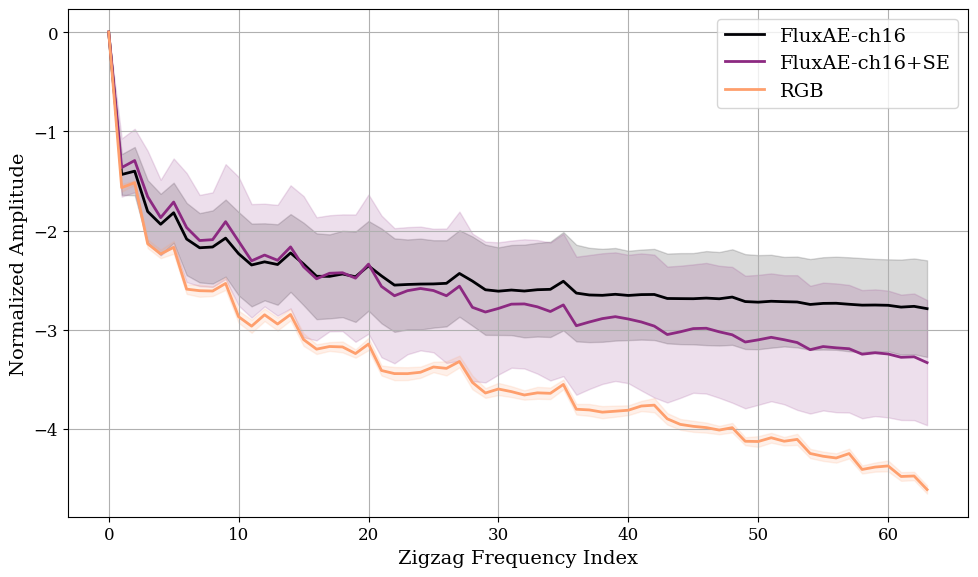

In [31]:
plot_spectrums_flat({k:np.log(s[2][:,0]) for k, s in spectrums.items()}, ylabel='Normalized Amplitude',
                     plot_average=True, disable_color_grad=False, external_legend=False, 
                     figsize=(10,6), save_path=f'./results/fluxae-ch_16_{image_size}.png')